In [33]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

## Weisfeiler Lehman kernel

We first explore a little bit the NetworkX support for Weisfeiler Lehman kernels. We start by looking at a small social network, the famous Zachary Karate club network (it doesn't really matter so much for us what this network is).

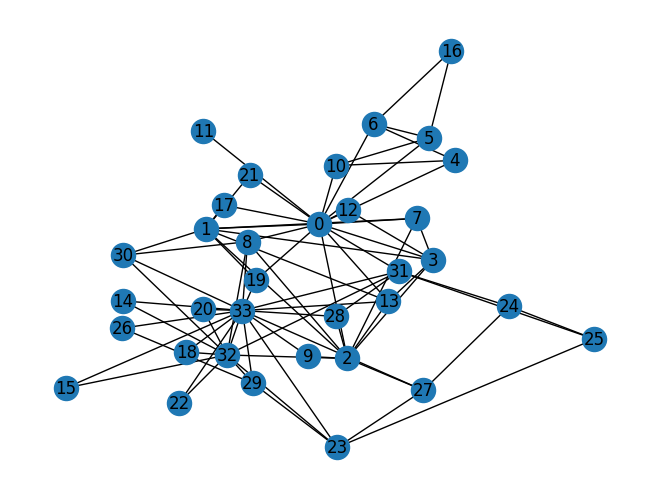

In [34]:
zachary = nx.karate_club_graph()
nx.draw_kamada_kawai(zachary,with_labels=True)

Add a "dummy attribute" to all nodes. This is not really necessary here, but it illustrates the handling of node attributes.  In the molecule data below we will use a meaningful (non-dummy) attribute.

In [35]:
for n in zachary.nodes():
    zachary.add_node(n, att="1")

Now perform 'numiterations' many iterations of Weisfeiler-Lehman updates, and print the codes at all iterations for a selections of nodes:

In [36]:

numiterations=5
Codes=nx.weisfeiler_lehman_subgraph_hashes(zachary,node_attr='att',digest_size=4,iterations=numiterations)

# Codes is a dictionary keyed by nodes. The entry for a node is the sequence of codes assigned to the node over the iterations

for i in [14,15,26,33]:
    print("{}:  {}".format(i,Codes[i]))


14:  ['7f96ed24', '631fd6bc', '765b8d48', 'e8b407dd', '386cc377']
15:  ['7f96ed24', '631fd6bc', '765b8d48', 'e8b407dd', '386cc377']
26:  ['7f96ed24', '9e69f4d3', '8dcf34f7', 'c02f3434', '4a680f1c']
33:  ['b5e585d0', '3f8e100f', '41f8ab23', '51da1b7b', '38a3e44a']


For a given iteration, we can simplify the codes to integer indices, and associate them with a color for visualization: 

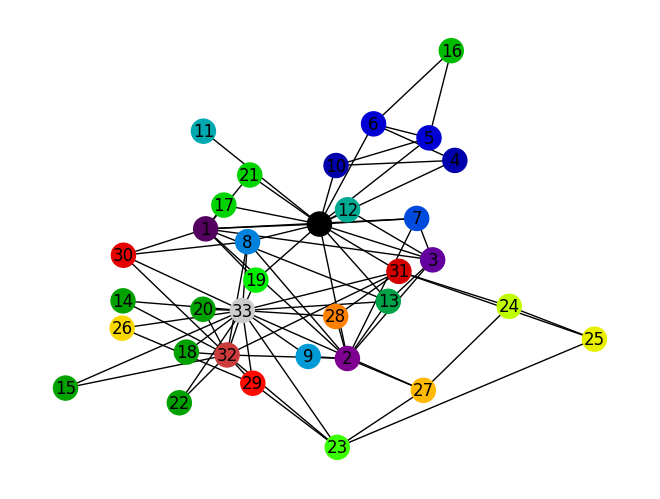

In [37]:
it=4 # pick an iteration number
dict={}
nextint=0
colors=np.zeros(zachary.order())


for i in range(zachary.order()):
    if not Codes[i][it-1] in dict:
        dict[Codes[i][it-1]]=nextint
        nextint+=1
    colors[i]=dict[Codes[i][it-1]]
        

nx.draw_kamada_kawai(zachary,with_labels=True,node_color=colors,cmap='nipy_spectral')
plt.show()



Computations for the graphs from the slides/exercises:

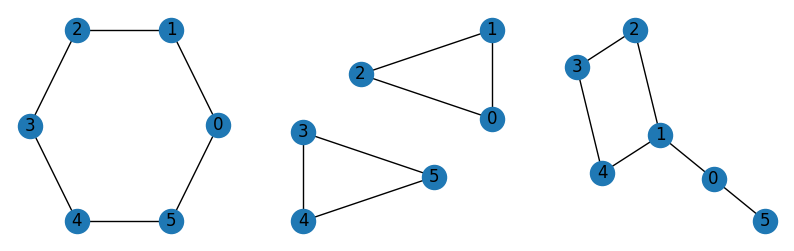

In [38]:
graphs=[]

G1 = nx.Graph()
G1.add_nodes_from(range(6))
G1.add_edges_from([(0,1),(1, 2), (2, 3),(3,4),(4,5),(5,0)])
for n in G1.nodes():
    G1.add_node(n, att="1")
graphs.append(G1)

G2 = nx.Graph()
G2.add_nodes_from(range(6))
G2.add_edges_from([(0,1),(1, 2), (2, 0),(3,4),(4,5),(5,3)])
for n in G2.nodes():
    G2.add_node(n, att="1")
graphs.append(G2)

G3 = nx.Graph()
G3.add_nodes_from(range(6))
G3.add_edges_from([(0,1),(1, 2), (2, 3),(3,4),(4,1),(5,0)])
for n in G3.nodes():
    G3.add_node(n, att="1")
graphs.append(G3)



fig,axes=plt.subplots(1,3,figsize=(10,3))

for i in range(len(graphs)):
    nx.draw_kamada_kawai(graphs[i],with_labels=True,ax=axes[i])


In [39]:
Codes=[]
for i in range(len(graphs)):
    Codes.append(nx.weisfeiler_lehman_subgraph_hashes(graphs[i],node_attr='att',digest_size=4,iterations=5))

for i in range(len(graphs)):
    print("Graph {} ".format(i))
    for key in Codes[i]:
        print(key, ' : ', Codes[i][key])
        
    


Graph 0 
0  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
1  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
2  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
3  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
4  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
5  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
Graph 1 
0  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
1  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
2  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
3  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
4  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
5  :  ['7f96ed24', '7fea2169', 'c5165520', '37fc135a', 'e96368f7']
Graph 2 
0  :  ['7f96ed24', '4f794a16', 'c46379b3', '7c98edad', '99af42ea']
1  :  ['b3f0e76b', '8e5b1604', 'e5ca5fe8', '44ee36cb', '80bb9d1b']
2  :  ['7f96ed24', '63bba71a', '24a

**Exercise:** implement the WL graph kernel based on the codes computed by weisfeiler_lehman_subgraph_hashes

Calculate the kernel matrices for h=1,2,3 for the 3 graphs G1,G2,G3

### NCI molecules

We use a molecule dataset available here: https://www.chrsmrrs.com/graphkerneldatasets/NCI1.zip

In [40]:
#Unzip the downloaded data in your datadir:
datadir="/home/toita86/Documents/AAU/ML/1-Manfred/3-Graph kernels/"

#Now read into np arrays:
all_edges=np.genfromtxt(datadir + "./NCI1/NCI1_A.txt",delimiter=",")
graphidx=np.genfromtxt(datadir + "./NCI1/NCI1_graph_indicator.txt",delimiter=",")
graphlabels=np.genfromtxt(datadir + "./NCI1/NCI1_graph_labels.txt",delimiter=",")
nodelabels=np.genfromtxt(datadir + "./NCI1/NCI1_node_labels.txt",delimiter=",")

Turning the data into a list of networkx graphs. Beware: node and graph indices in the source files are floats starting at 1.0 . This requires some casting to ints and subtracting -1 to get things right with the Python indices! 

In [41]:
#Initializing
molecules=[]
for i in range(int(np.max(graphidx))):
    molecules.append(nx.Graph())
#adding the nodes:    
for n in range(len(nodelabels)):
    molecules[int(graphidx[n])-1].add_node(n+1,label=nodelabels[n])
#adding the edges:
for i in range(len(all_edges)):
    e=all_edges[i].astype(int)
    if graphidx[e[0]-1] != graphidx[e[1]-1]:
        print("error!!! for edge {}".format(e))
    molecules[int(graphidx[e[0]-1])-1].add_edge(e[0],e[1])

print("Constructed ",len(molecules), " molecule graphs")

Constructed  4110  molecule graphs


Displaying a selection of the molecules

Molecule: 0  Label: 0.0


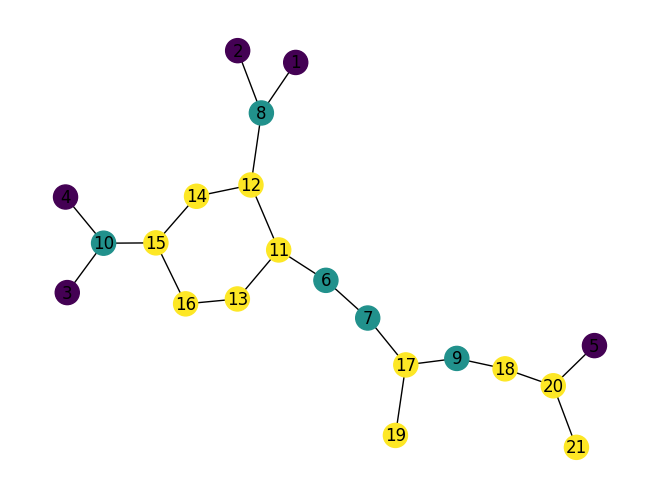

Molecule: 10  Label: 0.0


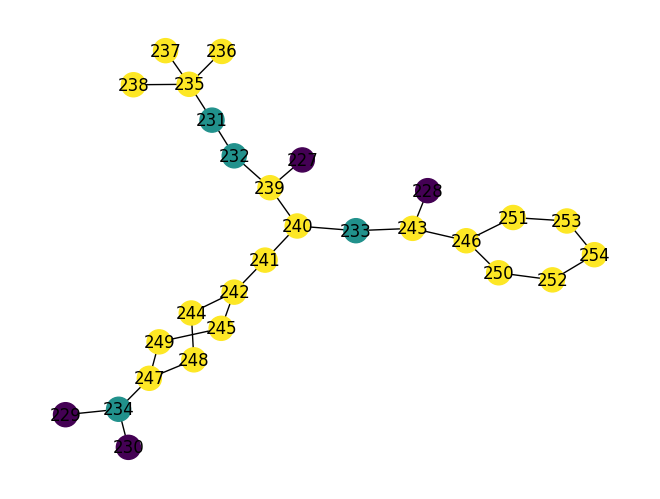

Molecule: 1202  Label: 0.0


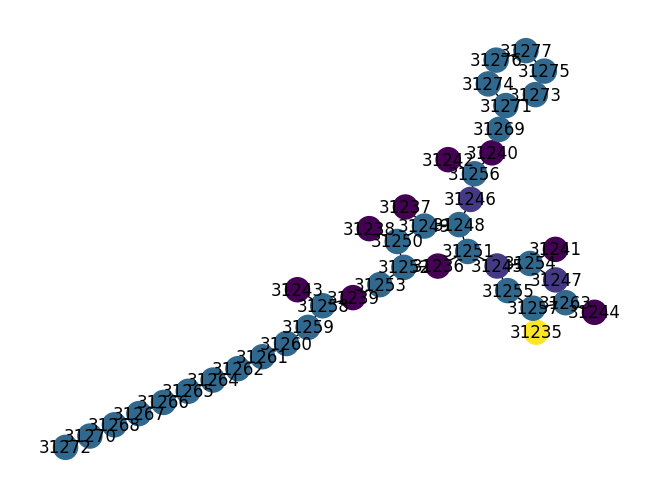

Molecule: 3199  Label: 1.0


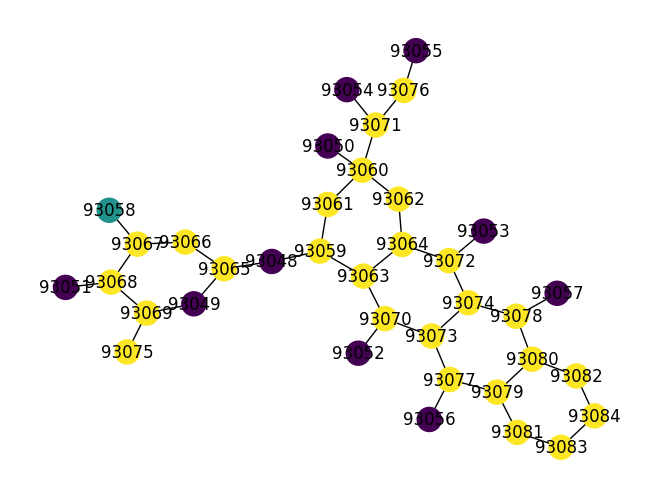

Molecule: 3200  Label: 1.0


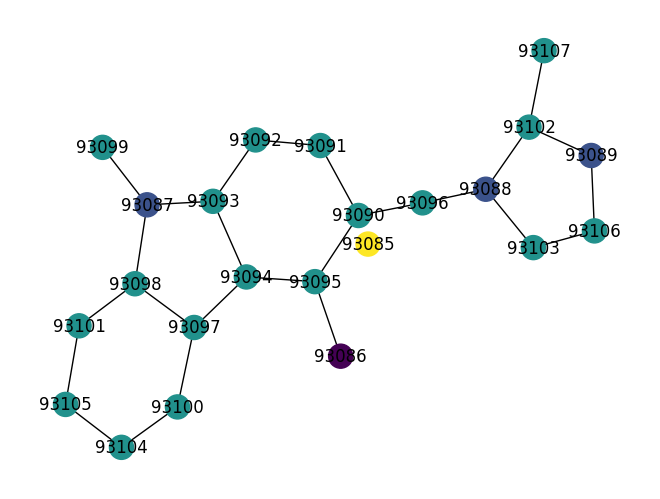

In [42]:
midxes=[0,10,1202,3199,3200]

for m in midxes:
    mol=molecules[m]
    ncols=np.zeros(mol.order())

    for i,n in enumerate(mol.nodes()):
        ncols[i]=mol.nodes[n]["label"]
    print("Molecule: {}  Label: {}".format(m,graphlabels[m]))
    nx.draw_kamada_kawai(mol,with_labels=True,node_color=ncols)
    plt.show()

**Exercise (self study)** Partition the molecule data into train and test set. Train a SVM classifier using the WL graph kernel with different values of h. See https://scikit-learn.org/stable/modules/svm.html#svm-classification Section 1.4.6.2 "Custom kernels"

In [44]:
# --- Exercise 2: SVM on NCI1 with WL kernel ---

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

# Build WL feature vectors for a list of graphs
# Returns (X, code_to_idx) so test can reuse the same feature space
def wl_features(graphs, attr="label", h_max=3, digest_size=4, code_to_idx=None):
    hist_list = []
    all_code_set = set() if code_to_idx is None else set(code_to_idx.keys())
    for G in graphs:
        codes = nx.weisfeiler_lehman_subgraph_hashes(
            G, node_attr=attr, digest_size=digest_size, iterations=h_max
        )
        hist = Counter()
        for node in codes:
            for hh in range(h_max):
                hist[codes[node][hh]] += 1
        hist_list.append(hist)
        if code_to_idx is None:
            all_code_set.update(hist.keys())
    if code_to_idx is None:
        all_codes = sorted(all_code_set)
        code_to_idx = {c: i for i, c in enumerate(all_codes)}
    n_features = len(code_to_idx)
    n_graphs = len(graphs)
    X = np.zeros((n_graphs, n_features))
    for i, hist in enumerate(hist_list):
        for code, count in hist.items():
            if code in code_to_idx:
                X[i, code_to_idx[code]] = count
    return X, code_to_idx

# Custom kernel: dot product in WL feature space
def wl_kernel(X, Y):
    return np.dot(X, Y.T)

# Prepare graphs and labels
X_graphs = molecules
y = graphlabels.astype(int)

# Balanced subset (200 per class)
np.random.seed(42)
idx0 = np.where(y == 0)[0]
idx1 = np.where(y == 1)[0]
n_per_class = 200
idx_sample = np.concatenate([
    np.random.choice(idx0, n_per_class, replace=False),
    np.random.choice(idx1, n_per_class, replace=False),
])
X_subset = [X_graphs[i] for i in idx_sample]
y_subset = y[idx_sample]

for h in [1, 2, 3]:
    # Build features on ALL data first to get consistent feature space
    X_all, code_to_idx = wl_features(X_subset, attr="label", h_max=h)
    # Then split the feature matrix
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_subset, test_size=0.3, random_state=42, stratify=y_subset
    )
    # Train SVM with custom WL kernel
    svm = SVC(kernel=wl_kernel, C=1.0)
    svm.fit(X_train, y_train)
    preds = svm.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"h={h}: SVM accuracy = {acc:.4f}")


h=1: SVM accuracy = 0.7167
h=2: SVM accuracy = 0.6833
h=3: SVM accuracy = 0.7750
